# Emotions Detector — Exploratory Data Analysis

Full analysis pass over `data/train.csv` (fer2013-style: `emotion`, `pixels`,
`usage` columns, 48x48 grayscale faces) before any training happens:

1. Load & structural checks (shape, dtypes, missing/duplicate rows)
2. Decode pixels into images, verify integrity
3. Class distribution & imbalance
4. Sample images per class
5. Average ("mean") face per class
6. Pixel intensity distributions (overall + per class)


In [ ]:
import sys, os
sys.path.append(os.path.abspath('../../scripts'))

import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from preprocess import EMOTIONS, IMG_SIZE, preprocess_dataframe

DATA_PATH = "../../data/train.csv"
OUT_DIR = "."

import os
os.makedirs(OUT_DIR, exist_ok=True)


## 1. Load & structural checks

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (28709, 2)


,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [6]:
print("Dtypes:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print(f"\nDuplicate rows (exact): {df.duplicated().sum()}")

if "usage" in df.columns:
    print(f"\nUsage split:\n{df['usage'].value_counts()}")

Dtypes:
emotion    int64
pixels       str
dtype: object

Missing values:
emotion    0
pixels     0
dtype: int64

Duplicate rows (exact): 1194


## 2. Decode pixels into images, verify integrity

Every `pixels` string should decode to exactly 48*48 = 2304 values in
[0, 255]. Flag any row that doesn't.

In [7]:
def pixel_len(s):
    return len(s.split())

lengths = df["pixels"].apply(pixel_len)
bad_rows = df[lengths != IMG_SIZE * IMG_SIZE]
print(f"Rows with unexpected pixel count: {len(bad_rows)} (expected {IMG_SIZE*IMG_SIZE})")

X, y = preprocess_dataframe(df)
print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"y shape: {y.shape}, unique labels: {sorted(np.unique(y).tolist())}")
print(f"Pixel value range after normalization: [{X.min():.3f}, {X.max():.3f}]")

# any all-black / all-white (corrupted) images?
flat = X.reshape(len(X), -1)
constant_imgs = np.where(flat.std(axis=1) == 0)[0]
print(f"Fully constant (blank) images: {len(constant_imgs)}")

Rows with unexpected pixel count: 0 (expected 2304)
X shape: (28709, 48, 48, 1), dtype: float32
y shape: (28709,), unique labels: [0, 1, 2, 3, 4, 5, 6]
Pixel value range after normalization: [0.000, 1.000]
Fully constant (blank) images: 11


## 3. Class distribution & imbalance

fer2013 is known to be imbalanced — `Disgust` typically has far fewer
examples than the rest. This affects loss choice (class weights) and how
you read accuracy vs. macro-F1 later.

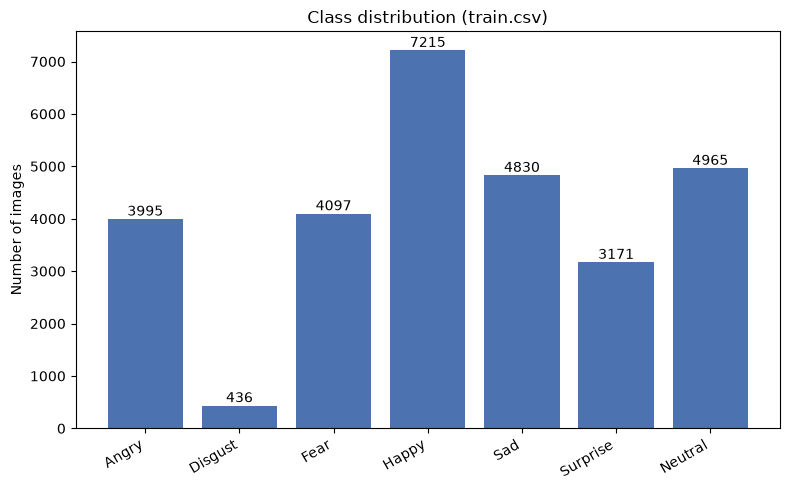

Angry        3995  (13.9%)
Disgust       436  (1.5%)
Fear         4097  (14.3%)
Happy        7215  (25.1%)
Sad          4830  (16.8%)
Surprise     3171  (11.0%)
Neutral      4965  (17.3%)

Imbalance ratio (largest / smallest class): 16.5x


In [ ]:
counts = np.bincount(y, minlength=len(EMOTIONS))
total = counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(EMOTIONS, counts, color="#4C72B0")
ax.set_title("Class distribution (train.csv)")
ax.set_ylabel("Number of images")
ax.bar_label(bars)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

for label, c in zip(EMOTIONS, counts):
    print(f"{label:<10} {c:>6}  ({c / total * 100:.1f}%)")

imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (largest / smallest class): {imbalance_ratio:.1f}x")

## 4. Sample images per class

Sanity-check that labels actually match what's in the image.

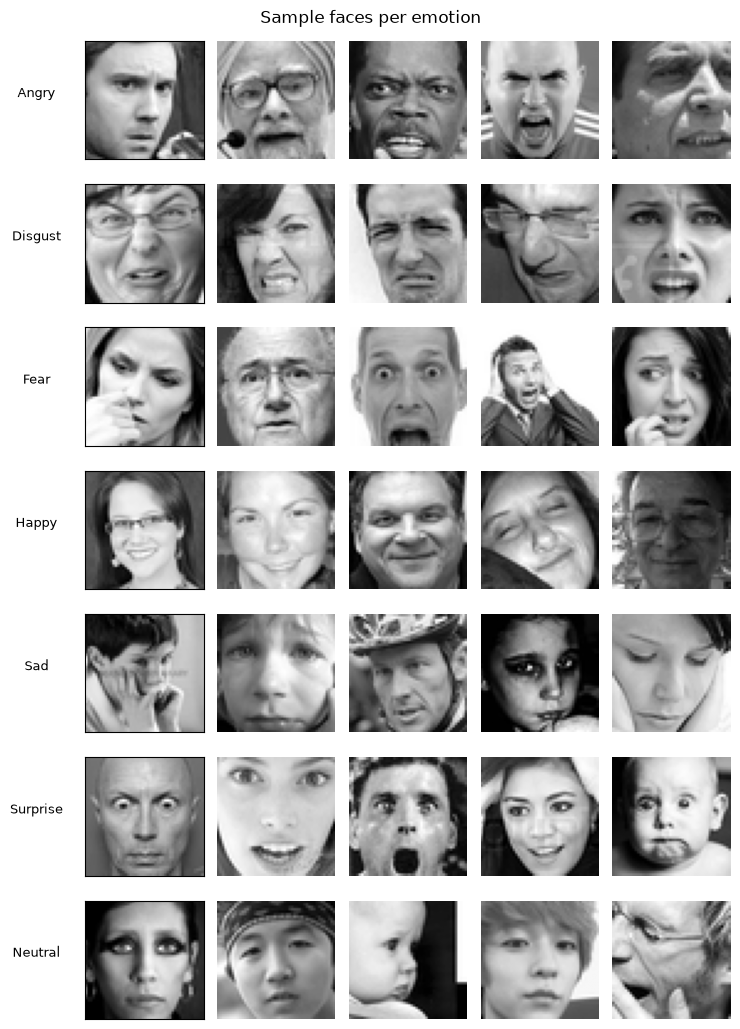

In [ ]:
per_class = 5
fig, axes = plt.subplots(len(EMOTIONS), per_class, figsize=(per_class * 1.5, len(EMOTIONS) * 1.5))

for row, label in enumerate(EMOTIONS):
    idxs = np.where(y == row)[0][:per_class]
    for col in range(per_class):
        ax = axes[row, col]
        ax.axis("off")
        if col < len(idxs):
            ax.imshow(X[idxs[col]].squeeze(), cmap="gray")
        if col == 0:
            ax.set_ylabel(label, rotation=0, labelpad=35, fontsize=9)
            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])

fig.suptitle("Sample faces per emotion")
plt.tight_layout()
plt.show()

## 5. Average ("mean") face per class

Averaging every image in a class blurs out individual variation and
highlights the class's dominant structure (e.g. Happy tends to show a
brighter mouth region from the smile).

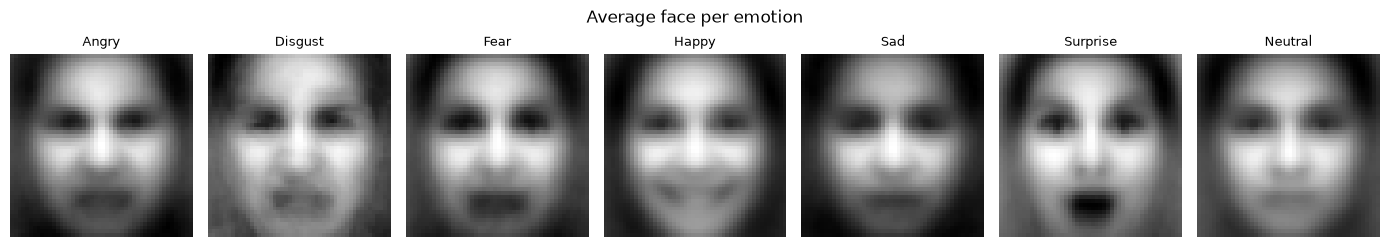

In [ ]:
fig, axes = plt.subplots(1, len(EMOTIONS), figsize=(len(EMOTIONS) * 2, 2.5))
for i, label in enumerate(EMOTIONS):
    mean_face = X[y == i].mean(axis=0).squeeze()
    axes[i].imshow(mean_face, cmap="gray")
    axes[i].set_title(label, fontsize=9)
    axes[i].axis("off")
fig.suptitle("Average face per emotion")
plt.tight_layout()
plt.show()

## 6. Pixel intensity distributions

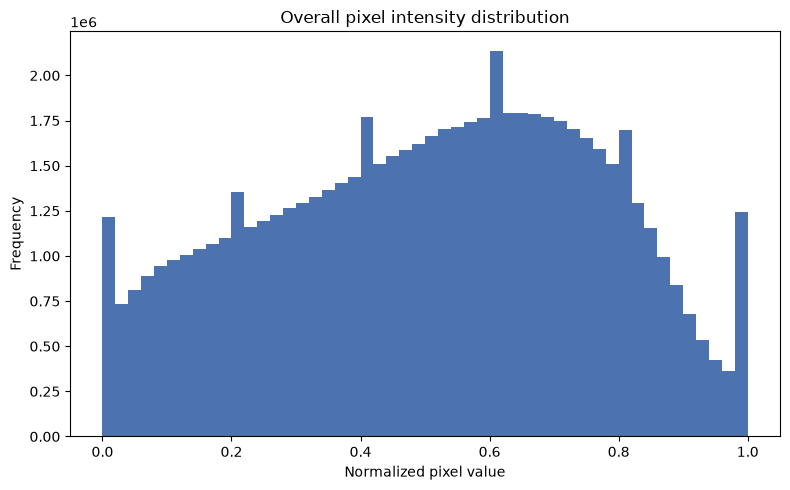

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(flat.flatten(), bins=50, color="#4C72B0")
ax.set_title("Overall pixel intensity distribution")
ax.set_xlabel("Normalized pixel value")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

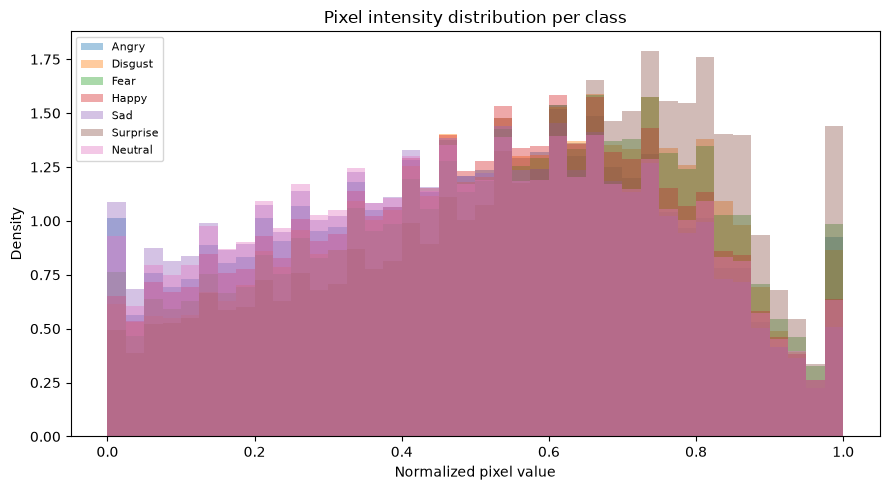

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, label in enumerate(EMOTIONS):
    class_pixels = flat[y == i].flatten()
    ax.hist(class_pixels, bins=40, alpha=0.4, label=label, density=True)
ax.set_title("Pixel intensity distribution per class")
ax.set_xlabel("Normalized pixel value")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
stats = []
for i, label in enumerate(EMOTIONS):
    imgs = X[y == i]
    if len(imgs) == 0:
        continue
    stats.append({
        "emotion": label,
        "mean": imgs.mean(),
        "std": imgs.std(),
        "min": imgs.min(),
        "max": imgs.max(),
        "n": len(imgs),
    })

stats_df = pd.DataFrame(stats).set_index("emotion")
stats_df.to_csv(f"{OUT_DIR}/pixel_stats.csv")
stats_df

,mean,std,min,max,n
emotion,,,,,
Angry,0.495030,0.255580,0.0,1.0,3995
Disgust,0.530305,0.248601,0.0,1.0,436
Fear,0.531452,0.254828,0.0,1.0,4097
Happy,0.507587,0.248461,0.0,1.0,7215
Sad,0.475588,0.254317,0.0,1.0,4830
Surprise,0.573579,0.254567,0.0,1.0,3171
Neutral,0.485883,0.256012,0.0,1.0,4965
